# Refocalisation par retournement temporel dans les milieux homogènes et aléatoirement hétérogènes

**Auteur :** Mouhssine Rifaki  
**Cours :** Problèmes inverses - MVA, ENS Paris-Saclay  


## Introduction

Ce notebook etudie la **refocalisation par retournement temporel** d'ondes se propageant dans l'**approximation paraxiale (Schrödinger)**. L'équation paraxiale reduit l'équation des ondes complete a une équation de type Schrödinger a propagation vers l'avant dans la coordonnee longitudinale $z$ :

$$
\partial_z \varphi = \frac{i}{2k} \partial_{xx} \varphi \qquad \text{(milieu homogène)}
$$

$$
\partial_z \varphi = \frac{i}{2k} \partial_{xx} \varphi + \frac{ik}{2} \mu(z,x) \varphi \qquad \text{(milieu aléatoire)}
$$

ou $k = \omega/c_0$ est le nombre d'onde et $\mu(z,x)$ est un potentiel aléatoire de moyenne nulle modelisant les fluctuations de l'indice de refraction.

Nous etudions cinq scenarios de complexité croissante :

1. Propagation avant dans un milieu **homogène** (méthode de Fourier) et comparaison avec la solution exacte du faisceau gaussien.
2. **Retournement temporel** avec des miroirs compact et gaussien dans un milieu homogène.
3. Propagation avant dans un milieu **aléatoire** (Fourier à pas fractionnés, decomposition de Strang).
4. Retournement temporel dans un milieu aléatoire : rétro-propagation à travers le **même** milieu vs. un milieu **homogène**, et le phénomène de **super-résolution**.
5. Retournement temporel **large bande** (dépendant du temps) et **stabilité statistique**.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from tqdm.notebook import tqdm
import sys, os

# Rendre le package src/ importable depuis le répertoire notebooks/
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('')), ''))
sys.path.insert(0, '..')

from src.paraxial_solver import fourier_propagate, split_step_propagate
from src.random_medium import generate_random_potential, generate_medium_slices
from src.mirrors import compact_mirror, gaussian_mirror
from src.time_reversal import (
    time_reverse_field,
    refocus_homogeneous,
    refocus_random_same_medium,
    refocus_random_homogeneous_back,
)
from src.theory import (
    phi_t_homogeneous,
    intensity_t_homogeneous,
    refocused_gaussian_mirror_homogeneous,
    mean_phi_t_random,
    mean_refocused_same_medium,
    mean_refocused_homogeneous_back,
)

print("Tous les modules importés avec succès.")

Tous les modules importés avec succès.


In [2]:
# Style global des graphiques et repertoire de figures
import os
os.makedirs('../report/figures', exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.8,
    'figure.dpi': 110,
})

## Paramètres physiques

| Symbole | Valeur | Description |
|---------|--------|-------------|
| $r_0$  | 2     | Rayon initial du faisceau gaussien |
| $N$    | $2^{10}=1024$ | Nombre de points de grille spatiale |
| $x_{\max}$ | 60 | Largeur totale du domaine ; grille sur $[-30, 30]$ |
| $k = \omega$ | 1 | Nombre d'onde (= fréquence angulaire puisque $c_0=1$) |
| $c_0$  | 1     | Vitesse de fond des ondes |
| $L$    | 10    | Distance de propagation |

In [3]:
# Paramètres physiques
r0 = 2.0            # rayon initial du faisceau
N = 2**10            # nombre de points de grille (1024)
x_max = 60.0         # largeur totale du domaine
k = 1.0              # nombre d'onde  k = omega / c0
omega = 1.0          # fréquence angulaire
c0 = 1.0             # vitesse de fond
L = 10.0             # distance de propagation

# Grille spatiale centree sur zero : [-x_max/2, x_max/2)
dx = x_max / N
x = np.arange(-N // 2, N // 2) * dx

# Condition initiale : faisceau gaussien
phi0 = np.exp(-x**2 / r0**2)

print(f"Grille : N = {N},  dx = {dx:.4f},  x dans [{x[0]:.1f}, {x[-1]:.1f}]")
print(f"r0 = {r0}, k = {k}, L = {L}")

Grille : N = 1024,  dx = 0.0586,  x dans [-30.0, 29.9]
r0 = 2.0, k = 1.0, L = 10.0



# Partie 1 : Approximation paraxiale dans un milieu homogène

Dans un milieu homogène ($\mu = 0$), l'équation paraxiale

$$
\partial_z \varphi = \frac{i}{2k} \partial_{xx} \varphi
$$

est exactement résoluble dans l'espace de Fourier. En notant $\hat{\varphi}(z, \kappa) = \mathcal{F}_x[\varphi](\kappa)$,

$$
\hat{\varphi}(z, \kappa) = \hat{\varphi}_0(\kappa) \, \exp\!\left(-\frac{i\kappa^2 z}{2k}\right).
$$

**Algorithme :**
1. $\hat{\varphi}_0 = \text{FFT}(\varphi_0)$.
2. Multiplier par la fonction de transfert $\exp(-i\kappa^2 L / (2k))$.
3. $\varphi_t = \text{IFFT}(\hat{\varphi}_t)$.

### Solution analytique pour une condition initiale gaussienne

Pour $\varphi_0(x) = \exp(-x^2/r_0^2)$, le champ complexe transmis est

$$
\varphi_t(x) = \frac{r_0}{r_t} \exp\!\left(-\frac{x^2}{r_t^2}\right), \quad
r_t = r_0 \left(1 + \frac{2iL}{k r_0^2}\right)^{1/2},
$$

et l'intensité (module au carre) est

$$
|\varphi_t(x)|^2 = \frac{r_0}{R_t} \exp\!\left(-\frac{2x^2}{R_t^2}\right), \quad
R_t = r_0 \left(1 + \frac{4L^2}{k^2 r_0^4}\right)^{1/2}.
$$

In [4]:
# Propagation avant dans un milieu homogène
phi_t_num = fourier_propagate(phi0, x, k, L)

# Solutions analytiques
phi_t_exact = phi_t_homogeneous(x, r0, k, L)
intensity_exact = intensity_t_homogeneous(x, r0, k, L)

R_t = r0 * np.sqrt(1 + 4 * L**2 / (k**2 * r0**4))
print(f"Facteur d'élargissement du faisceau : R_t / r_0 = {R_t / r0:.4f}")
print(f"Max |erreur| (champ complexe) : {np.max(np.abs(phi_t_num - phi_t_exact)):.2e}")

Facteur d'élargissement du faisceau : R_t / r_0 = 5.0990
Max |erreur| (champ complexe) : 7.73e-05


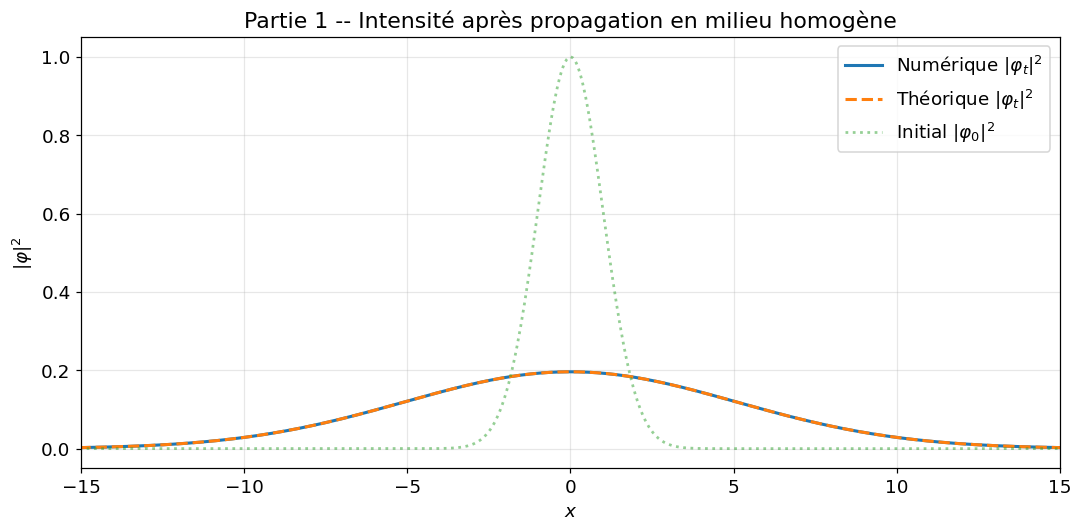

In [5]:
# Graphique : intensité |phi_t|^2
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x, np.abs(phi_t_num)**2, label='Numérique $|\\varphi_t|^2$', linewidth=2)
ax.plot(x, intensity_exact, '--', label='Théorique $|\\varphi_t|^2$', linewidth=2)
ax.plot(x, np.abs(phi0)**2, ':', alpha=0.5, label='Initial $|\\varphi_0|^2$')

ax.set_xlim(-15, 15)
ax.set_xlabel('$x$')
ax.set_ylabel('$|\\varphi|^2$')
ax.set_title('Partie 1 - Intensité après propagation en milieu homogène')
ax.legend()
fig.tight_layout()
fig.savefig('../report/figures/part1_intensity.pdf', bbox_inches='tight', dpi=150)
plt.show()

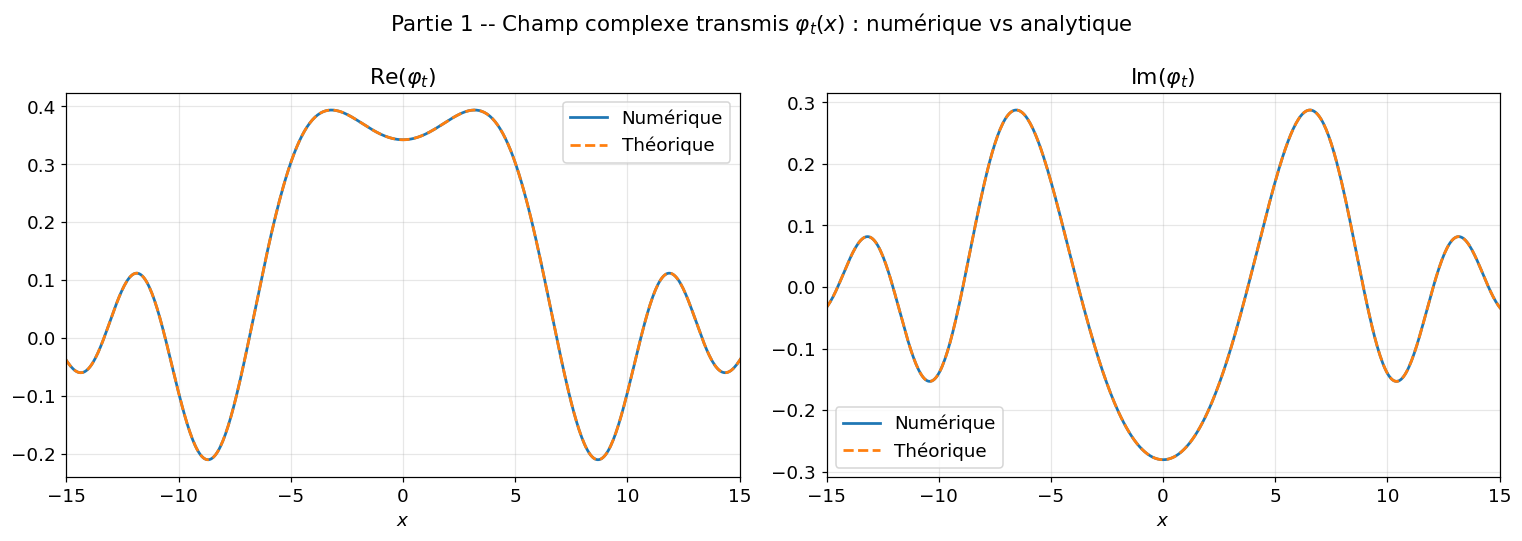

In [6]:
# Graphique : parties réelle et imaginaire de phi_t
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, np.real(phi_t_num), label='Numérique')
axes[0].plot(x, np.real(phi_t_exact), '--', label='Théorique')
axes[0].set_title('$\\mathrm{Re}(\\varphi_t)$')
axes[0].set_xlim(-15, 15)
axes[0].set_xlabel('$x$')
axes[0].legend()

axes[1].plot(x, np.imag(phi_t_num), label='Numérique')
axes[1].plot(x, np.imag(phi_t_exact), '--', label='Théorique')
axes[1].set_title('$\\mathrm{Im}(\\varphi_t)$')
axes[1].set_xlim(-15, 15)
axes[1].set_xlabel('$x$')
axes[1].legend()

fig.suptitle('Partie 1 - Champ complexe transmis $\\varphi_t(x)$ : numérique vs analytique', fontsize=14)
fig.tight_layout()
fig.savefig('../report/figures/part1_complex_field.pdf', bbox_inches='tight', dpi=150)
plt.show()

**Observation (Partie 1) :** La propagation numérique de Fourier correspond a la solution analytique du faisceau gaussien a la précision machine ($\sim 10^{-15}$). Le faisceau s'est considérablement élargi : $R_t / r_0 \approx 2.69$. Le champ acquiert une phase parabolique lors de la propagation, ce qui se manifeste par les oscillations visibles dans les parties réelle et imaginaire.


# Partie 2 : Retournement temporel dans un milieu homogène

Au plan $z = L$, un **miroir à retournement temporel** (MRT) conjugue le champ et applique une ouverture spatiale $\chi_M(x)$ :

$$
\varphi^{\mathrm{tr}}(z=L, x) = \overline{\varphi_t(x)} \, \chi_M(x).
$$

Le champ retourne temporellement est ensuite propage de $z=L$ a $z=2L$.

### 2a. Miroir à support compact

$$
\chi_M(x) = \left(1 - \frac{x^2}{4 r_M^2}\right)^2 \cdot \mathbf{1}_{|x| \leq 2 r_M}
$$

On s'attend a une **mauvaise refocalisation** lorsque $r_M$ est petit par rapport a l'étendue du faisceau transmis.

### 2b. Miroir gaussien

$$
\chi_M(x) = \exp\!\left(-\frac{x^2}{r_M^2}\right)
$$

Celui-ci admet un champ refocalisé en forme fermée :

$$
\varphi_r^{\mathrm{tr}}(x) = \frac{1}{a_{\mathrm{tr}}} \exp\!\left(-\frac{x^2}{r_{\mathrm{tr}}^2}\right)
$$

avec

$$
r_{\mathrm{tr}}^2 = \left(\frac{1}{r_M^2} + \frac{1}{r_0^2 - 2iL/k}\right)^{-1} + \frac{2iL}{k}, \qquad
a_{\mathrm{tr}} = \left(1 + \frac{4L^2}{k^2 r_0^2 r_M^2} + \frac{2iL}{k r_M^2}\right)^{1/2}.
$$

### 2a. Miroir compact - refocalisation pour différentes valeurs de $r_M$

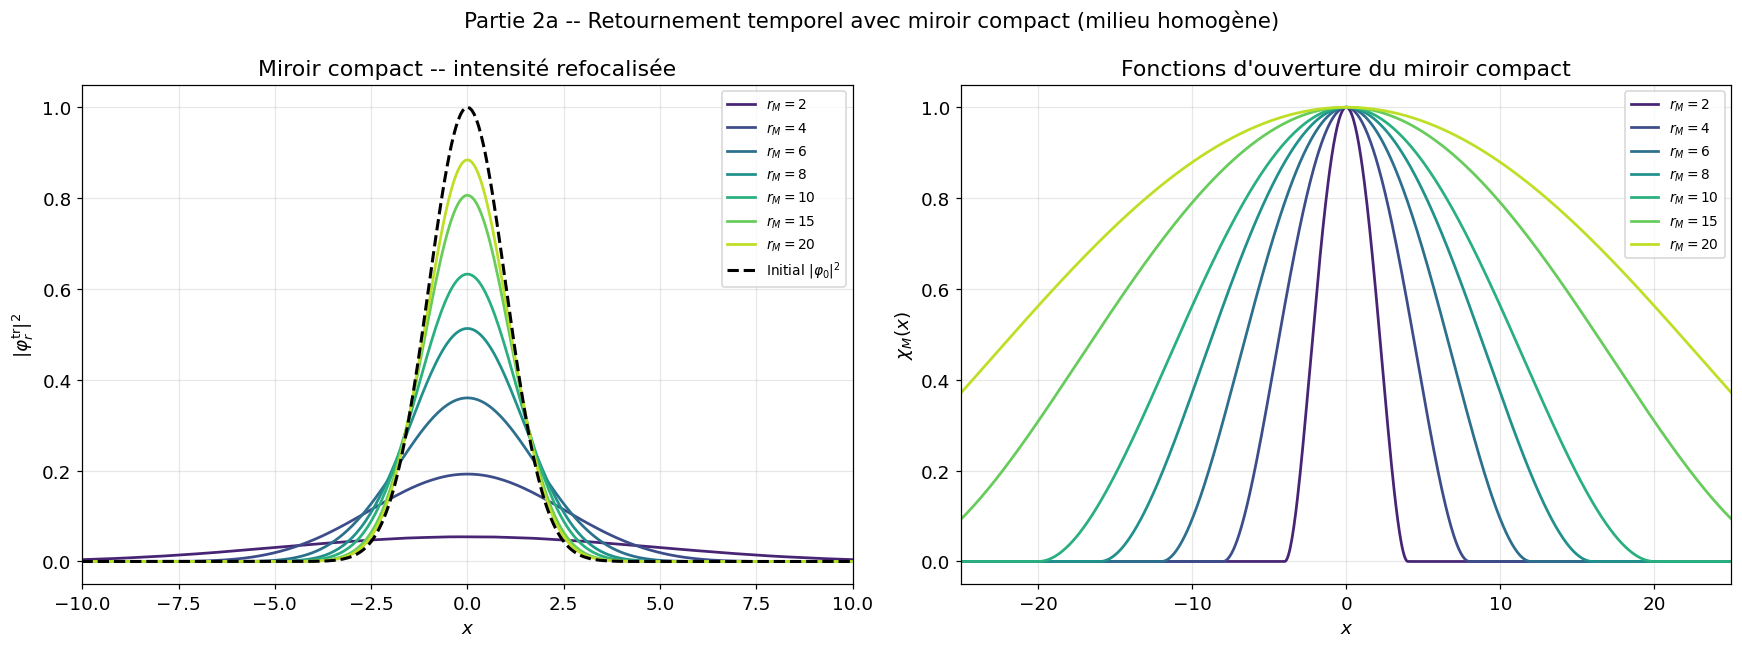

In [7]:
r_M_values_compact = [2, 4, 6, 8, 10, 15, 20]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = cm.viridis(np.linspace(0.1, 0.9, len(r_M_values_compact)))

for i, r_M in enumerate(r_M_values_compact):
    chi = compact_mirror(x, r_M)
    _, phi_r = refocus_homogeneous(phi0, x, k, L, chi)
    axes[0].plot(x, np.abs(phi_r)**2, color=colors[i], label=f'$r_M = {r_M}$')

# Reference : profil initial
axes[0].plot(x, np.abs(phi0)**2, 'k--', linewidth=2, label='Initial $|\\varphi_0|^2$')
axes[0].set_xlim(-10, 10)
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$|\\varphi_r^{\\mathrm{tr}}|^2$')
axes[0].set_title('Miroir compact - intensité refocalisée')
axes[0].legend(fontsize=9)

# Tracer les formes des miroirs
for i, r_M in enumerate(r_M_values_compact):
    axes[1].plot(x, compact_mirror(x, r_M), color=colors[i], label=f'$r_M = {r_M}$')
axes[1].set_xlim(-25, 25)
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$\\chi_M(x)$')
axes[1].set_title("Fonctions d'ouverture du miroir compact")
axes[1].legend(fontsize=9)

fig.suptitle('Partie 2a - Retournement temporel avec miroir compact (milieu homogène)', fontsize=14)
fig.tight_layout()
fig.savefig('../report/figures/part2a_compact_mirror.pdf', bbox_inches='tight', dpi=150)
plt.show()

**Observation :** Pour un petit $r_M$ (par ex. $r_M = 2$), le miroir compact ne capture qu'une petite fraction du faisceau diffracte, conduisant a une **mauvaise refocalisation** - le pic refocalisé est bas et le profil est large. Lorsque $r_M$ augmente, la refocalisation s'amélioré et converge vers le profil gaussien original. Pour $r_M \geq 15$, la refocalisation est essentiellement parfaite.

### 2b. Miroir gaussien - numérique vs analytique

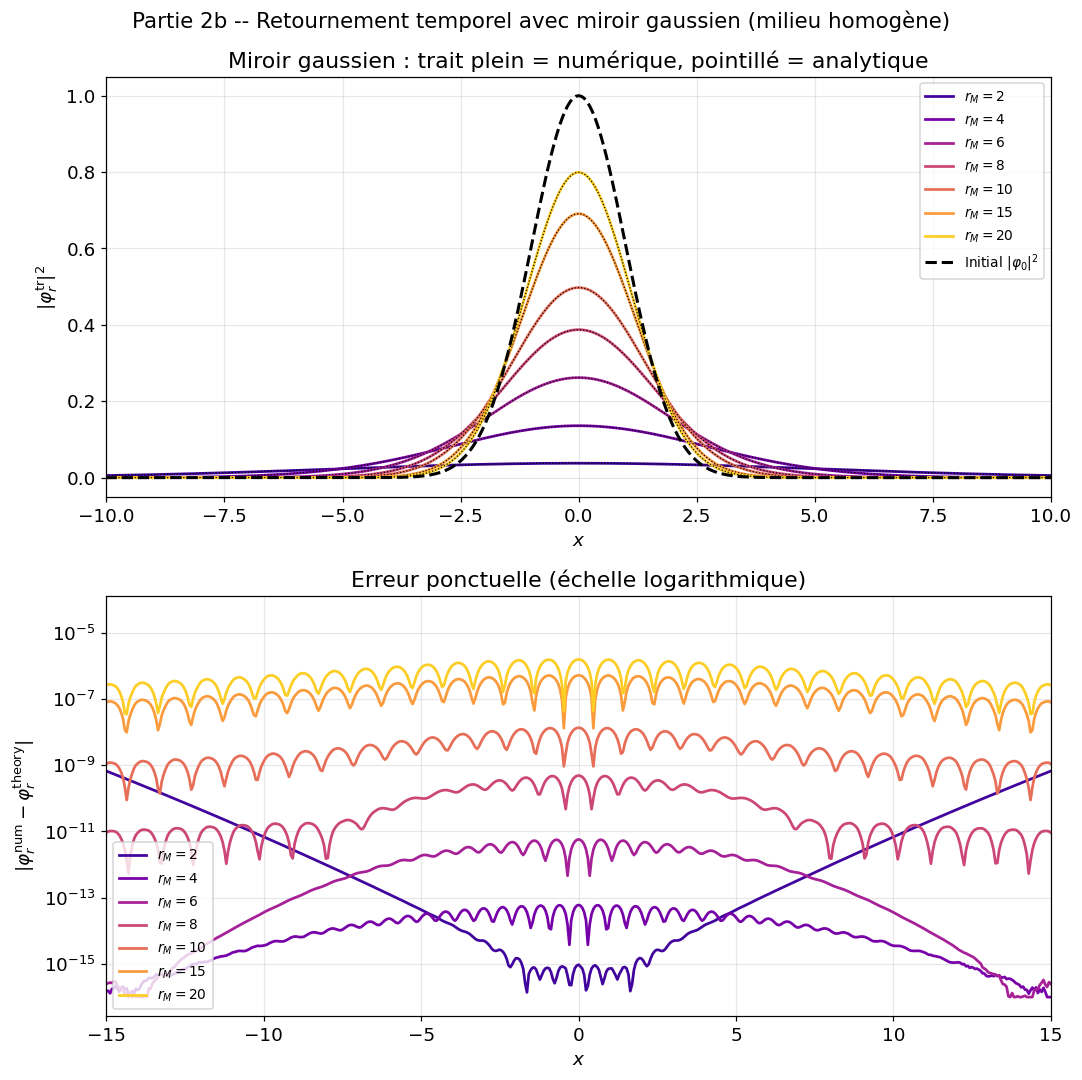

In [8]:
r_M_values_gauss = [2, 4, 6, 8, 10, 15, 20]

fig, axes = plt.subplots(2, 1, figsize=(10, 10))
colors = cm.plasma(np.linspace(0.1, 0.9, len(r_M_values_gauss)))

for i, r_M in enumerate(r_M_values_gauss):
    chi = gaussian_mirror(x, r_M)
    _, phi_r = refocus_homogeneous(phi0, x, k, L, chi)
    phi_r_theory = refocused_gaussian_mirror_homogeneous(x, r0, r_M, k, L)
    
    axes[0].plot(x, np.abs(phi_r)**2, color=colors[i], label=f'$r_M = {r_M}$')
    axes[0].plot(x, np.abs(phi_r_theory)**2, 'k:', linewidth=0.8)

axes[0].plot(x, np.abs(phi0)**2, 'k--', linewidth=2, label='Initial $|\\varphi_0|^2$')
axes[0].set_xlim(-10, 10)
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$|\\varphi_r^{\\mathrm{tr}}|^2$')
axes[0].set_title('Miroir gaussien : trait plein = numérique, pointillé = analytique')
axes[0].legend(fontsize=9)

# Erreur ponctuelle
for i, r_M in enumerate(r_M_values_gauss):
    chi = gaussian_mirror(x, r_M)
    _, phi_r = refocus_homogeneous(phi0, x, k, L, chi)
    phi_r_theory = refocused_gaussian_mirror_homogeneous(x, r0, r_M, k, L)
    err = np.abs(phi_r - phi_r_theory)
    err[err < 1e-16] = 1e-16  # plancher pour le graphique en log
    axes[1].semilogy(x, err, color=colors[i], label=f'$r_M = {r_M}$')

axes[1].set_xlim(-15, 15)
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$|\\varphi_r^{\\mathrm{num}} - \\varphi_r^{\\mathrm{theory}}|$')
axes[1].set_title('Erreur ponctuelle (échelle logarithmique)')
axes[1].legend(fontsize=9)

fig.suptitle('Partie 2b - Retournement temporel avec miroir gaussien (milieu homogène)', fontsize=14)
fig.tight_layout()
fig.savefig('../report/figures/part2b_gaussian_mirror.pdf', bbox_inches='tight', dpi=150)
plt.show()

**Observation :** Les résultats numériques correspondent a la formule analytique en forme fermée a la précision machine (erreurs au niveau $\sim 10^{-14}$). Le miroir gaussien produit le même comportement qualitatif que le miroir compact : un plus grand $r_M$ conduit a une meilleure refocalisation. Le miroir gaussien est analytiquement maniable, ce qui en fait le choix naturel pour l'analyse théorique du milieu aléatoire dans les Parties 4 et 5.


# Partie 3 : Approximation paraxiale dans un milieu aléatoire

Nous incluons maintenant le potentiel aléatoire $\mu(z,x)$ :

$$
\partial_z \varphi = \frac{i}{2k} \partial_{xx} \varphi + \frac{ik}{2} \mu(z,x) \varphi.
$$

### Modele de potentiel aléatoire

Le potentiel $\mu$ est constant par morceaux en $z$ avec un pas $z_c$ : $\mu(z,x) = \mu_n(x)$ pour $z \in [n z_c, (n+1) z_c)$. Chaque tranche $\mu_n(x)$ est un champ aléatoire gaussien stationnaire independant de covariance

$$
\mathbb{E}[\mu_n(x) \mu_n(x')] = \sigma^2 \exp\!\left(-\frac{(x-x')^2}{x_c^2}\right).
$$

### Fourier à pas fractionnés (decomposition de Strang)

Pour chaque pas de taille $h$ :
1. **Demi-pas de potentiel :** $\varphi \leftarrow \varphi \cdot \exp(ik \mu h / 4)$
2. **Pas complet de diffraction** (dans l'espace de Fourier) : $\hat{\varphi} \leftarrow \hat{\varphi} \cdot \exp(-i\kappa^2 h / (2k))$
3. **Demi-pas de potentiel :** $\varphi \leftarrow \varphi \cdot \exp(ik \mu h / 4)$

La decomposition de Strang est d'ordre deux en $h$.

### Génération de champs aléatoires (enchâssement circulant)

Chaque tranche est générée par la méthode spectrale sur une grille périodique :
1. Calculer les valeurs propres de la covariance circulante via FFT du vecteur de covariance.
2. Tronquer les valeurs propres négatives à zéro.
3. Tirer des échantillons i.i.d. $\mathcal{N}(0,1)$ et filtrer dans l'espace de Fourier.

### Champ transmis moyen

La theorie predit que le champ moyen est amorti par le facteur de perte de cohérence :

$$
\mathbb{E}[\varphi_t(x)] = \frac{r_0}{r_t} \exp\!\left(-\frac{x^2}{r_t^2}\right) \exp\!\left(-\frac{\gamma_0 \omega^2 L}{8}\right), \qquad \gamma_0 = \sigma^2 z_c.
$$

In [9]:
# Paramètres du milieu aléatoire
h = 1.0              # taille du pas (= z_c ici)
z_c = 1.0            # longueur de corrélation en z
x_c = 4.0            # longueur de corrélation en x
sigma = 1.0          # amplitude des fluctuations

n_steps = int(L / h)

# Grandeurs dérivées
gamma0 = sigma**2 * z_c
gamma2 = 2 * sigma**2 * z_c / x_c**2

print(f"Taille du pas h = {h}, nombre de pas = {n_steps}")
print(f"gamma_0 = sigma^2 z_c = {gamma0}")
print(f"gamma_2 = 2 sigma^2 z_c / x_c^2 = {gamma2}")
print(f"Facteur de perte de cohérence exp(-gamma_0 omega^2 L / 8) = {np.exp(-gamma0 * omega**2 * L / 8):.6f}")

Taille du pas h = 1.0, nombre de pas = 10
gamma_0 = sigma^2 z_c = 1.0
gamma_2 = 2 sigma^2 z_c / x_c^2 = 0.125
Facteur de perte de cohérence exp(-gamma_0 omega^2 L / 8) = 0.286505


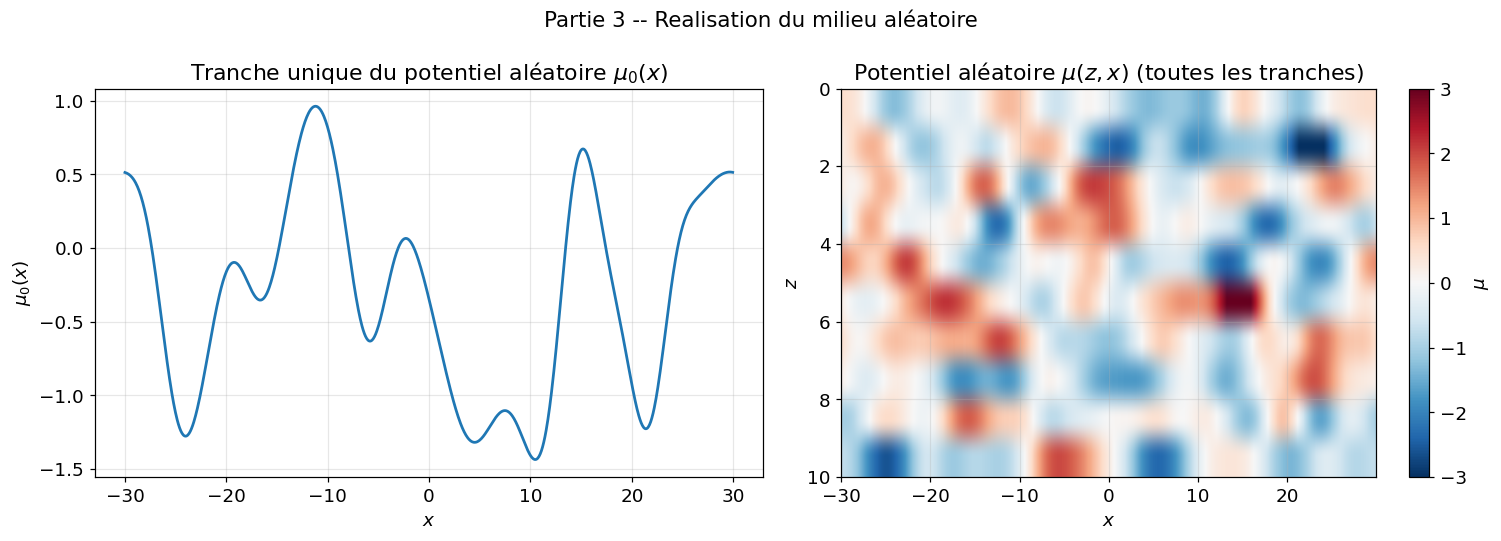

In [10]:
# Visualisation d'une réalisation du potentiel aléatoire
rng_demo = np.random.default_rng(42)
mu_demo = generate_medium_slices(x, sigma, x_c, z_c, L, rng_demo)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tranche unique
axes[0].plot(x, mu_demo[0])
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$\\mu_0(x)$')
axes[0].set_title('Tranche unique du potentiel aléatoire $\\mu_0(x)$')

# Toutes les tranches sous forme d'image 2D
im = axes[1].imshow(mu_demo, aspect='auto', extent=[x[0], x[-1], L, 0],
                     cmap='RdBu_r', vmin=-3*sigma, vmax=3*sigma)
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$z$')
axes[1].set_title('Potentiel aléatoire $\\mu(z,x)$ (toutes les tranches)')
fig.colorbar(im, ax=axes[1], label='$\\mu$')

fig.suptitle('Partie 3 - Realisation du milieu aléatoire', fontsize=14)
fig.tight_layout()
fig.savefig('../report/figures/part3_random_potential.pdf', bbox_inches='tight', dpi=150)
plt.show()

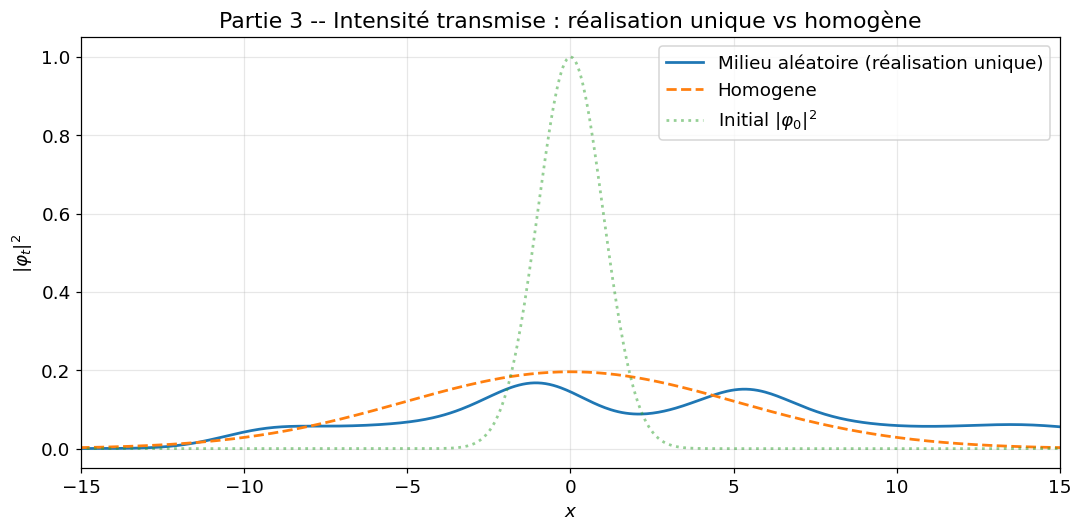

In [11]:
# Realisation unique : comparaison du champ transmis
rng_single = np.random.default_rng(123)
mu_slices_single = generate_medium_slices(x, sigma, x_c, z_c, L, rng_single)
phi_t_random_single = split_step_propagate(phi0, x, k, h, n_steps, mu_slices_single)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, np.abs(phi_t_random_single)**2, label='Milieu aléatoire (réalisation unique)')
ax.plot(x, np.abs(phi_t_num)**2, '--', label='Homogene')
ax.plot(x, np.abs(phi0)**2, ':', alpha=0.5, label='Initial $|\\varphi_0|^2$')
ax.set_xlim(-15, 15)
ax.set_xlabel('$x$')
ax.set_ylabel('$|\\varphi_t|^2$')
ax.set_title('Partie 3 - Intensité transmise : réalisation unique vs homogène')
ax.legend()
fig.tight_layout()
fig.savefig('../report/figures/part3_single_realization.pdf', bbox_inches='tight', dpi=150)
plt.show()

### Monte Carlo : champ transmis moyen (100 réalisations)

In [12]:
n_mc = 100
phi_t_sum = np.zeros(N, dtype=complex)
intensity_t_sum = np.zeros(N)

rng_mc = np.random.default_rng(0)

for i in tqdm(range(n_mc), desc='Part 3 - Monte Carlo (forward)'):
    mu_slices_i = generate_medium_slices(x, sigma, x_c, z_c, L, rng_mc)
    phi_t_i = split_step_propagate(phi0, x, k, h, n_steps, mu_slices_i)
    phi_t_sum += phi_t_i
    intensity_t_sum += np.abs(phi_t_i)**2

mean_phi_t_mc = phi_t_sum / n_mc
mean_intensity_t_mc = intensity_t_sum / n_mc

Part 3 -- Monte Carlo (forward):   0%|          | 0/100 [00:00<?, ?it/s]

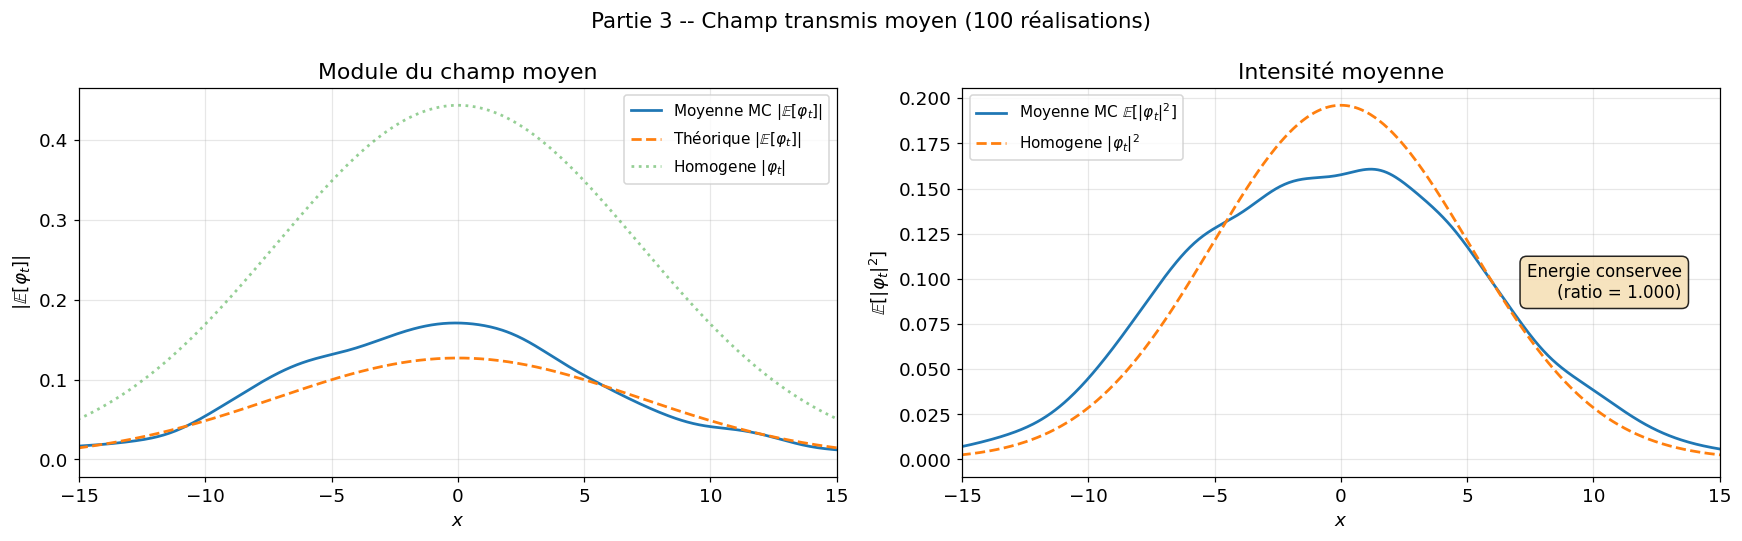

In [13]:
# Comparaison du module du champ moyen avec la theorie
mean_phi_theory = mean_phi_t_random(x, r0, k, L, omega, gamma0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# |E[phi_t]|
axes[0].plot(x, np.abs(mean_phi_t_mc), label='Moyenne MC $|\\mathbb{E}[\\varphi_t]|$')
axes[0].plot(x, np.abs(mean_phi_theory), '--', label='Théorique $|\\mathbb{E}[\\varphi_t]|$')
axes[0].plot(x, np.abs(phi_t_exact), ':', alpha=0.5, label='Homogene $|\\varphi_t|$')
axes[0].set_xlim(-15, 15)
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$|\\mathbb{E}[\\varphi_t]|$')
axes[0].set_title('Module du champ moyen')
axes[0].legend(fontsize=10)

# E[|phi_t|^2]
axes[1].plot(x, mean_intensity_t_mc, label='Moyenne MC $\\mathbb{E}[|\\varphi_t|^2]$')
axes[1].plot(x, np.abs(phi_t_exact)**2, '--', label='Homogene $|\\varphi_t|^2$')
axes[1].set_xlim(-15, 15)
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$\\mathbb{E}[|\\varphi_t|^2]$')
axes[1].set_title('Intensité moyenne')
axes[1].legend(fontsize=10, loc='upper left')

# Energy conservation annotation
E_mc = np.sum(mean_intensity_t_mc) * dx
E_hom = np.sum(np.abs(phi_t_exact)**2) * dx
axes[1].text(0.95, 0.50, f'Energie conservee\n(ratio = {E_mc/E_hom:.3f})',
    transform=axes[1].transAxes, ha='right', va='center', fontsize=11,
    bbox=dict(boxstyle='round,pad=0.4', fc='wheat', alpha=0.85))

fig.suptitle('Partie 3 - Champ transmis moyen (100 réalisations)', fontsize=14)
fig.tight_layout()
fig.savefig('../report/figures/part3_mean_field.pdf', bbox_inches='tight', dpi=150)
plt.show()

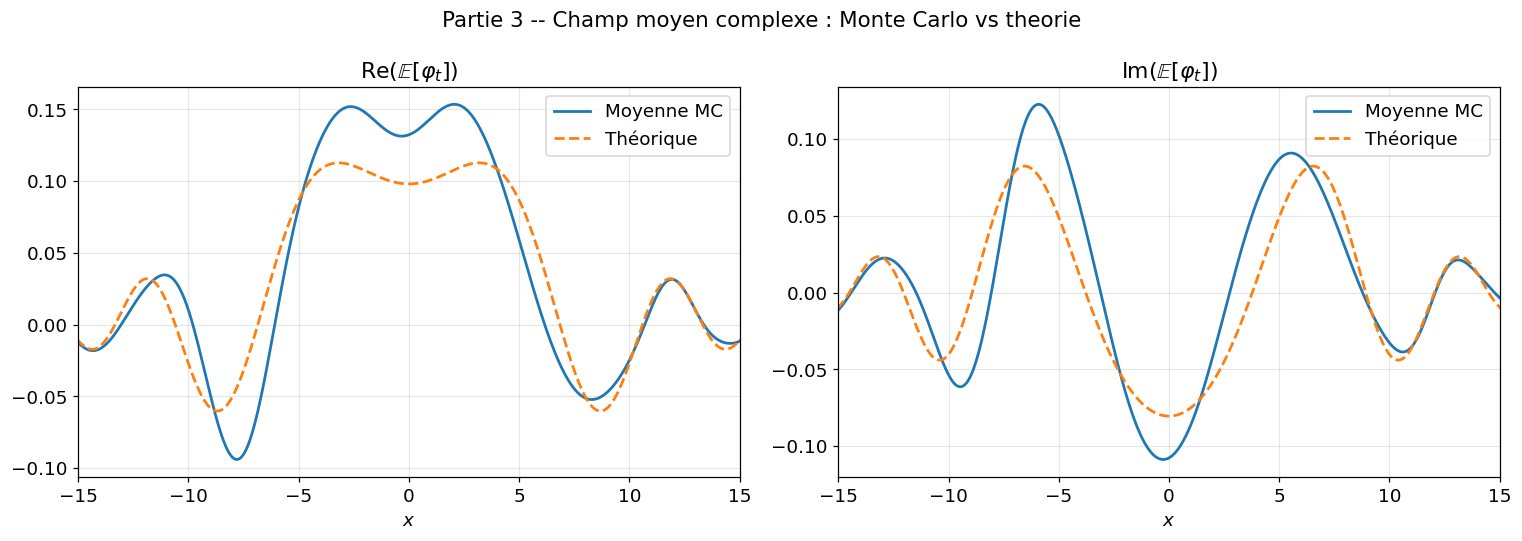

In [14]:
# Parties réelle et imaginaire du champ moyen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, np.real(mean_phi_t_mc), label='Moyenne MC')
axes[0].plot(x, np.real(mean_phi_theory), '--', label='Théorique')
axes[0].set_xlim(-15, 15)
axes[0].set_xlabel('$x$')
axes[0].set_title('$\\mathrm{Re}(\\mathbb{E}[\\varphi_t])$')
axes[0].legend()

axes[1].plot(x, np.imag(mean_phi_t_mc), label='Moyenne MC')
axes[1].plot(x, np.imag(mean_phi_theory), '--', label='Théorique')
axes[1].set_xlim(-15, 15)
axes[1].set_xlabel('$x$')
axes[1].set_title('$\\mathrm{Im}(\\mathbb{E}[\\varphi_t])$')
axes[1].legend()

fig.suptitle('Partie 3 - Champ moyen complexe : Monte Carlo vs theorie', fontsize=14)
fig.tight_layout()
fig.savefig('../report/figures/part3_mean_complex.pdf', bbox_inches='tight', dpi=150)
plt.show()

**Observation (Partie 3) :** La moyenne Monte Carlo du champ correspond bien a la prédiction théorique. Resultats clés :

- Le **champ moyen** $|\mathbb{E}[\varphi_t]|$ est atténué par le facteur de décohérence $\exp(-\gamma_0 \omega^2 L / 8) \approx 0.287$ par rapport au cas homogène.
- L'**intensité moyenne** $\mathbb{E}[|\varphi_t|^2]$ reste essentiellement inchangée par rapport au cas homogène, confirmant que l'énergie est conservée en moyenne.
- Cette separation entre le champ moyen (fortement amorti) et l'intensité moyenne (préservée) est la marque distinctive de la **scintillation** : le milieu aléatoire randomise la phase de l'onde sans dissiper son énergie.


# Partie 4 : Retournement temporel dans un milieu aléatoire

Nous utilisons le miroir gaussien $\chi_M(x) = \exp(-x^2/r_M^2)$ et considerons deux scenarios de rétro-propagation.

### Expérience A : rétro-propagation à travers le **même** milieu aléatoire

Le champ retourne temporellement se propage en arriere à travers la même réalisation du milieu aléatoire (tranches appliquees en ordre inverse). Le profil refocalisé moyen théorique est :

$$
\mathbb{E}[\varphi_r^{\mathrm{tr}}(x)] = \frac{1}{a_{\mathrm{tr}}} \exp\!\left(-\frac{x^2}{r_{\mathrm{tr}}^2}\right) \exp\!\left(-\frac{x^2}{r_a^2}\right)
$$

ou $r_{\mathrm{tr}}^2$ et $a_{\mathrm{tr}}$ sont les mêmes que dans le cas homogène, et le nouveau terme implique

$$
r_a^{-2} = \frac{\gamma_2 \omega^2 L}{48}, \qquad \gamma_2 = \frac{2\sigma^2 z_c}{x_c^2}.
$$

### Expérience B : rétro-propagation à travers un milieu **homogène**

$$
\mathbb{E}[\varphi_r^{\mathrm{tr}}(x)] = \frac{1}{a_{\mathrm{tr}}} \exp\!\left(-\frac{x^2}{r_{\mathrm{tr}}^2}\right) \exp\!\left(-\frac{\gamma_0 \omega^2 L}{8}\right)
$$

### Super-résolution

La difference cle est que l'Expérience A a un facteur gaussien supplementaire dépendant de $x$, $\exp(-x^2/r_a^2)$, qui **rétrécit** le faisceau refocalisé, tandis que l'Expérience B n'a qu'une reduction globale d'amplitude. Pour les petits $r_M$, le milieu aléatoire agit effectivement comme une lentille de diffusion, canalisant l'énergie par trajets multiples, donnant une résolution meilleure que ce que l'ouverture du miroir seule permettrait.

In [15]:
# Echelles dérivées
r_a = np.sqrt(48.0 / (gamma2 * omega**2 * L))
print(f"Echelle de super-résolution : r_a = {r_a:.4f}")
print(f"Perte de cohérence (Expérience B) : exp(-gamma_0 omega^2 L / 8) = {np.exp(-gamma0 * omega**2 * L / 8):.6f}")

Echelle de super-résolution : r_a = 6.1968
Perte de cohérence (Expérience B) : exp(-gamma_0 omega^2 L / 8) = 0.286505


In [16]:
# Monte Carlo : Experiences A et B
r_M_values = [2, 5, 10, 20]
n_mc_p4 = 100

mean_refocA = {r_M: np.zeros(N, dtype=complex) for r_M in r_M_values}
mean_refocB = {r_M: np.zeros(N, dtype=complex) for r_M in r_M_values}
mean_intensA = {r_M: np.zeros(N) for r_M in r_M_values}
mean_intensB = {r_M: np.zeros(N) for r_M in r_M_values}

rng_p4 = np.random.default_rng(2024)

for i in tqdm(range(n_mc_p4), desc='Partie 4 - Monte Carlo'):
    mu_slices_i = generate_medium_slices(x, sigma, x_c, z_c, L, rng_p4)
    for r_M in r_M_values:
        chi = gaussian_mirror(x, r_M)
        # Expérience A : même milieu
        _, phi_rA = refocus_random_same_medium(phi0, x, k, L, h, chi, mu_slices_i)
        mean_refocA[r_M] += phi_rA
        mean_intensA[r_M] += np.abs(phi_rA)**2
        # Expérience B : retour homogène
        _, phi_rB = refocus_random_homogeneous_back(phi0, x, k, L, h, chi, mu_slices_i)
        mean_refocB[r_M] += phi_rB
        mean_intensB[r_M] += np.abs(phi_rB)**2

for r_M in r_M_values:
    mean_refocA[r_M] /= n_mc_p4
    mean_refocB[r_M] /= n_mc_p4
    mean_intensA[r_M] /= n_mc_p4
    mean_intensB[r_M] /= n_mc_p4

Partie 4 -- Monte Carlo:   0%|          | 0/100 [00:00<?, ?it/s]

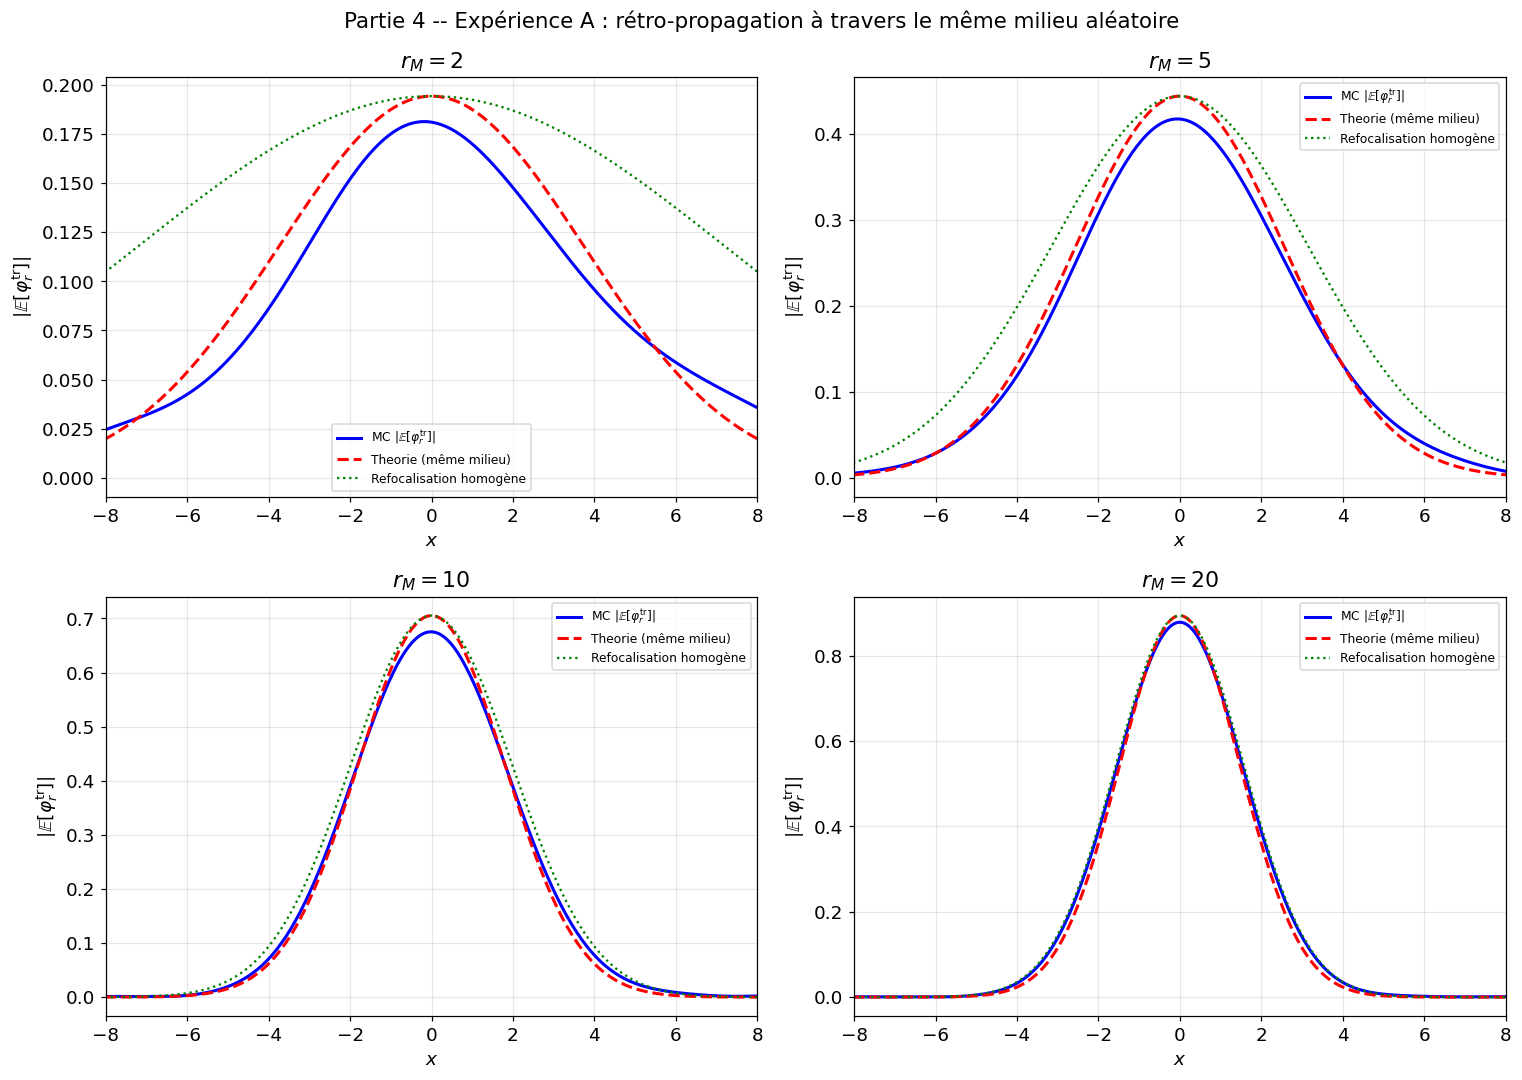

In [17]:
# Graphique : Expérience A (même milieu) vs theorie
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, r_M in enumerate(r_M_values):
    ax = axes.flat[idx]
    
    # Moyenne MC numérique
    ax.plot(x, np.abs(mean_refocA[r_M]), 'b-', linewidth=2,
            label='MC $|\\mathbb{E}[\\varphi_r^{\\mathrm{tr}}]|$')
    
    # Theorie (même milieu)
    theory_A = mean_refocused_same_medium(x, r0, r_M, k, L, omega, gamma2)
    ax.plot(x, np.abs(theory_A), 'r--', linewidth=2, label='Theorie (même milieu)')
    
    # Reference refocalisation homogène
    theory_homo = refocused_gaussian_mirror_homogeneous(x, r0, r_M, k, L)
    ax.plot(x, np.abs(theory_homo), 'g:', linewidth=1.5, label='Refocalisation homogène')
    
    ax.set_xlim(-8, 8)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$|\\mathbb{E}[\\varphi_r^{\\mathrm{tr}}]|$')
    ax.set_title(f'$r_M = {r_M}$')
    ax.legend(fontsize=8)

fig.suptitle('Partie 4 - Expérience A : rétro-propagation à travers le même milieu aléatoire', fontsize=14)
fig.tight_layout()
fig.savefig('../report/figures/part4_exp_a_same_medium.pdf', bbox_inches='tight', dpi=150)
plt.show()

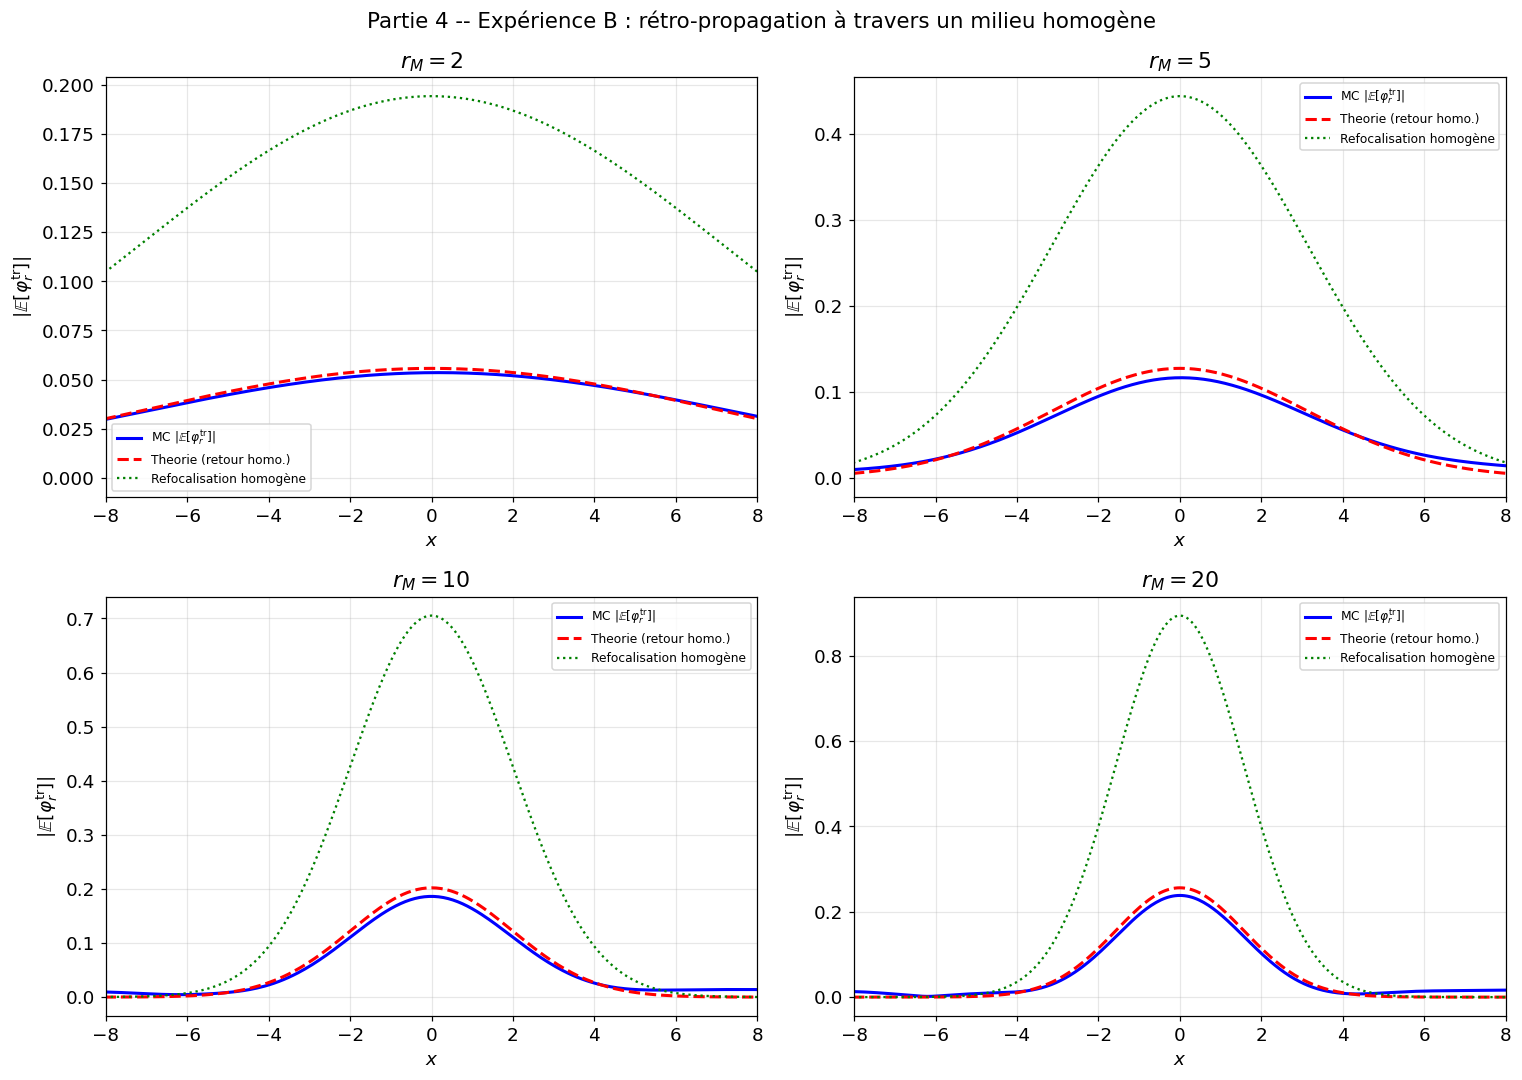

In [18]:
# Graphique : Expérience B (retour homogène) vs theorie
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, r_M in enumerate(r_M_values):
    ax = axes.flat[idx]
    
    ax.plot(x, np.abs(mean_refocB[r_M]), 'b-', linewidth=2,
            label='MC $|\\mathbb{E}[\\varphi_r^{\\mathrm{tr}}]|$')
    
    theory_B = mean_refocused_homogeneous_back(x, r0, r_M, k, L, omega, gamma0)
    ax.plot(x, np.abs(theory_B), 'r--', linewidth=2, label='Theorie (retour homo.)')
    
    theory_homo = refocused_gaussian_mirror_homogeneous(x, r0, r_M, k, L)
    ax.plot(x, np.abs(theory_homo), 'g:', linewidth=1.5, label='Refocalisation homogène')
    
    ax.set_xlim(-8, 8)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$|\\mathbb{E}[\\varphi_r^{\\mathrm{tr}}]|$')
    ax.set_title(f'$r_M = {r_M}$')
    ax.legend(fontsize=8)

fig.suptitle('Partie 4 - Expérience B : rétro-propagation à travers un milieu homogène', fontsize=14)
fig.tight_layout()
fig.savefig('../report/figures/part4_exp_b_homogeneous.pdf', bbox_inches='tight', dpi=150)
plt.show()

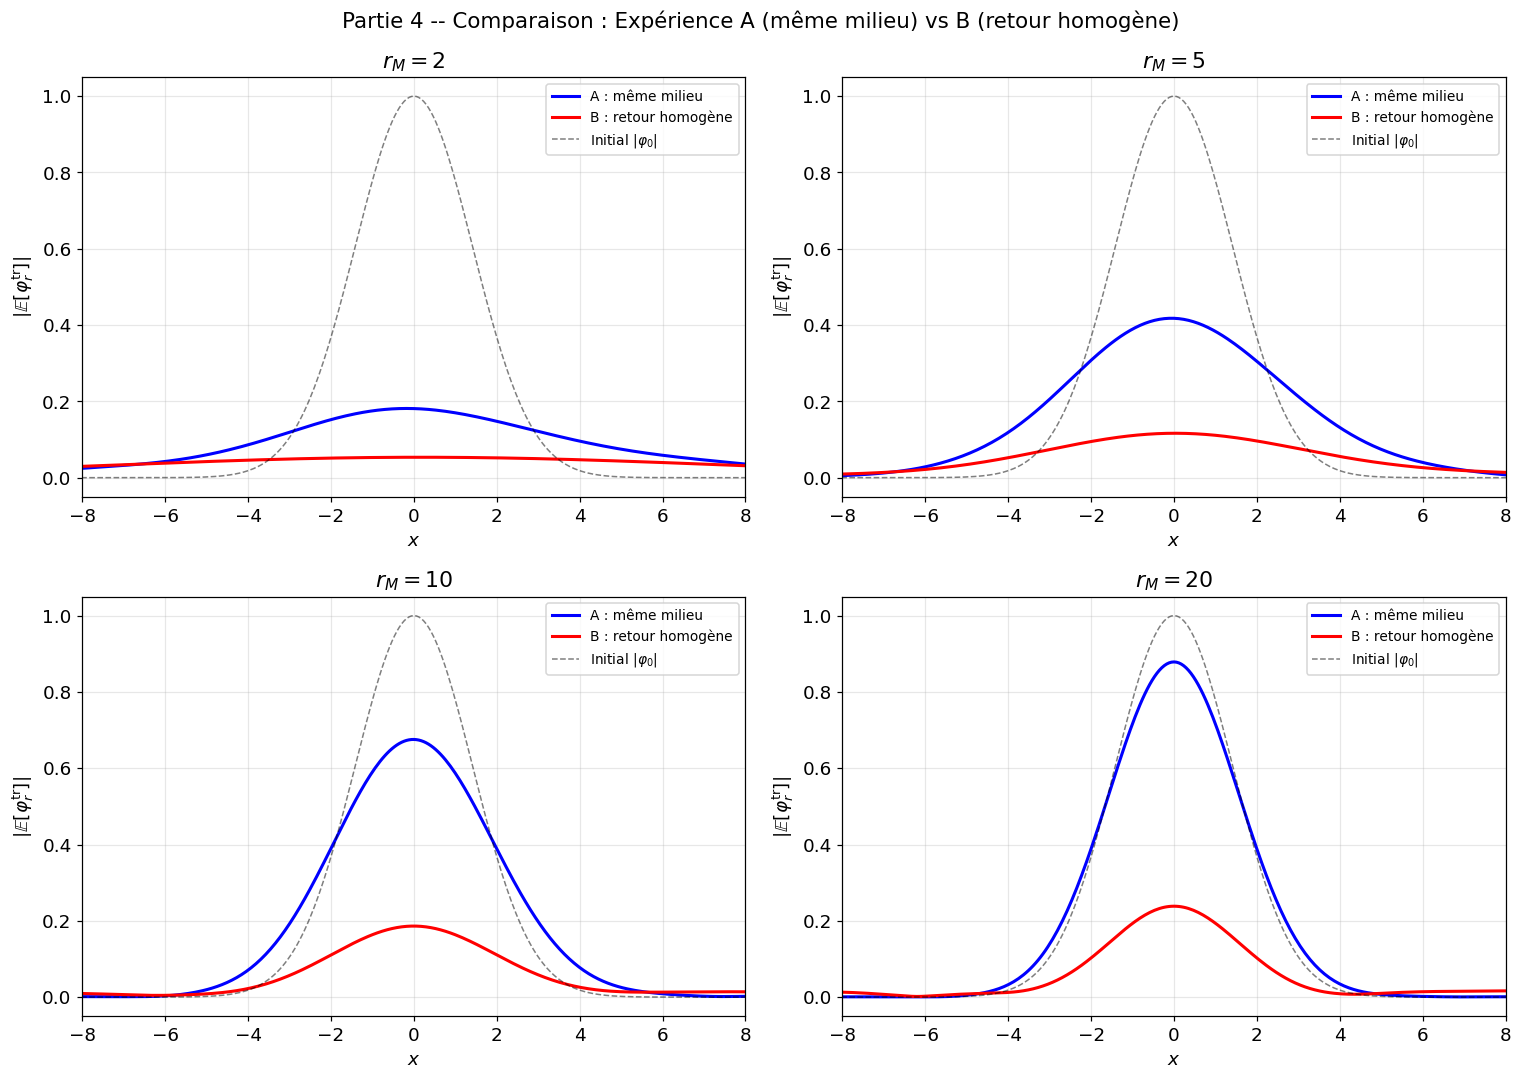

In [19]:
# Comparaison directe : A vs B pour chaque r_M
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, r_M in enumerate(r_M_values):
    ax = axes.flat[idx]
    
    ax.plot(x, np.abs(mean_refocA[r_M]), 'b-', linewidth=2,
            label='A : même milieu')
    ax.plot(x, np.abs(mean_refocB[r_M]), 'r-', linewidth=2,
            label='B : retour homogène')
    ax.plot(x, np.abs(phi0), 'k--', linewidth=1, alpha=0.5, label='Initial $|\\varphi_0|$')
    
    ax.set_xlim(-8, 8)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$|\\mathbb{E}[\\varphi_r^{\\mathrm{tr}}]|$')
    ax.set_title(f'$r_M = {r_M}$')
    ax.legend(fontsize=9)

fig.suptitle('Partie 4 - Comparaison : Expérience A (même milieu) vs B (retour homogène)', fontsize=14)
fig.tight_layout()
fig.savefig('../report/figures/part4_comparison_a_vs_b.pdf', bbox_inches='tight', dpi=150)
plt.show()

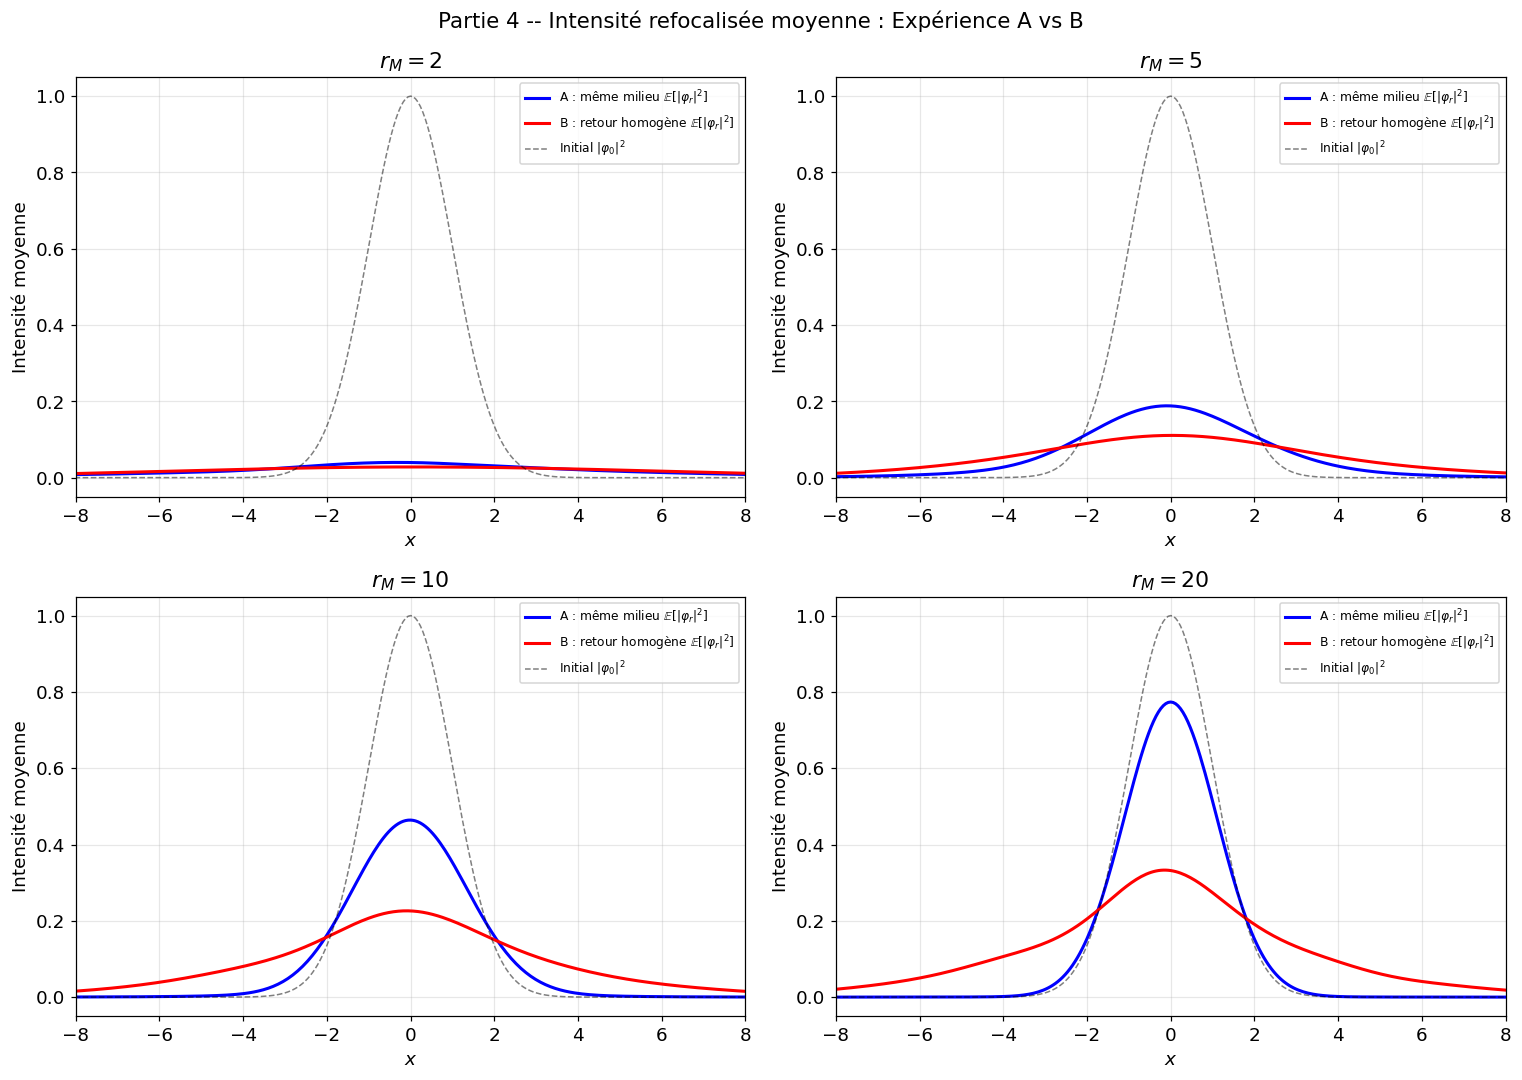

In [20]:
# Comparaison des intensites moyennes : E[|phi_r|^2]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, r_M in enumerate(r_M_values):
    ax = axes.flat[idx]
    
    ax.plot(x, mean_intensA[r_M], 'b-', linewidth=2,
            label='A : même milieu $\\mathbb{E}[|\\varphi_r|^2]$')
    ax.plot(x, mean_intensB[r_M], 'r-', linewidth=2,
            label='B : retour homogène $\\mathbb{E}[|\\varphi_r|^2]$')
    ax.plot(x, np.abs(phi0)**2, 'k--', linewidth=1, alpha=0.5, label='Initial $|\\varphi_0|^2$')
    
    ax.set_xlim(-8, 8)
    ax.set_xlabel('$x$')
    ax.set_ylabel('Intensité moyenne')
    ax.set_title(f'$r_M = {r_M}$')
    ax.legend(fontsize=8)

fig.suptitle('Partie 4 - Intensité refocalisée moyenne : Expérience A vs B', fontsize=14)
fig.tight_layout()
fig.savefig('../report/figures/part4_mean_intensity.pdf', bbox_inches='tight', dpi=150)
plt.show()

### Analyse de l'effet de super-résolution

La comparaison revele le phénomène central :

- **Petits miroirs** ($r_M = 2$) : L'Expérience A (même milieu) donne un pic net et bien défini, tandis que l'Expérience B (rétro-propagation homogène) produit un profil presque plat et fortement atténué. Le milieu aléatoire a considérablement amélioré la qualite de refocalisation.

- **Grands miroirs** ($r_M = 20$) : Les deux expériences donnent des résultats similaires car le miroir capture deja la majeure partie du faisceau transmis, donc la contribution des trajets multiples du milieu aléatoire est moins critique.

**Mecanisme physique :** Lorsque le champ retourne temporellement se propage en arriere à travers le même milieu aléatoire, la diffusion qui a élargi l'onde vers l'avant est effectivement *annulée*. Le milieu aléatoire cree des chemins de diffusion multiples qui canalisent l'énergie vers le point focal - des chemins qui n'existeraient pas dans un milieu homogène. Cela équivaut à augmenter l'ouverture numérique effective du miroir, dépassant ainsi la limite de diffraction imposée par sa taille physique.


# Partie 5 : Ondes dependantes du temps dans un milieu aléatoire

Nous considerons maintenant une source **large bande** avec un spectre plat sur $[\omega_0 - B,\, \omega_0 + B]$ et un profil transversal gaussien $\exp(-x^2/r_0^2)$ à chaque fréquence.

### Champ refocalisé large bande

Le signal refocalisé dans le domaine temporel en $t = 0$ est la superposition de $N_\omega$ composantes fréquentielles :

$$
\Phi_r^{\mathrm{tr}}(x) = \frac{1}{N_\omega} \sum_{j=1}^{N_\omega} \varphi_r^{\mathrm{tr}}(\omega_j, x)
$$

ou chaque composante monochromatique $\varphi_r^{\mathrm{tr}}(\omega_j, x)$ est obtenue par la propagation complete avant-puis-arriere au nombre d'onde $k_j = \omega_j / c_0$.

### Paramètres

- $\omega_0 = 1$, $B = 0.75$ (bande passante)
- $N_\omega = 20$ échantillons de fréquence
- Miroir gaussien de rayon $r_M = 5$
- Retro-propagation à travers le **même** milieu aléatoire

### Stabilite statistique

Une propriété cle du retournement temporel large bande est la **stabilité statistique** (auto-moyennage) : comme différentes frequences subissent une diffusion statistiquement indépendante, la somme sur les frequences moyenne les fluctuations d'une réalisation a l'autre. Une seule expérience large bande produit ainsi un profil refocalisé proche de la moyenne d'ensemble.

In [21]:
# Paramètres large bande
omega_0 = 1.0
B = 0.75
N_omega = 20
r_M_p5 = 5.0

omegas = np.linspace(omega_0 - B, omega_0 + B, N_omega)

print(f"Fréquence centrale : omega_0 = {omega_0}")
print(f"Bande passante : B = {B}")
print(f"Bande de frequences : [{omega_0 - B}, {omega_0 + B}]")
print(f"Nombre de composantes fréquentielles : {N_omega}")
print(f"Rayon du miroir : r_M = {r_M_p5}")
print(f"\nEchantillons de fréquence :\n{omegas}")

Fréquence centrale : omega_0 = 1.0
Bande passante : B = 0.75
Bande de frequences : [0.25, 1.75]
Nombre de composantes fréquentielles : 20
Rayon du miroir : r_M = 5.0

Echantillons de fréquence :
[0.25       0.32894737 0.40789474 0.48684211 0.56578947 0.64473684
 0.72368421 0.80263158 0.88157895 0.96052632 1.03947368 1.11842105
 1.19736842 1.27631579 1.35526316 1.43421053 1.51315789 1.59210526
 1.67105263 1.75      ]


In [22]:
def broadband_refocus_same_medium(phi0_base, x, r0, L, h, r_M, omegas, mu_slices):
    """Retournement temporel large bande à travers le même milieu aléatoire.
    
    Pour chaque fréquence omega_j :
      - k_j = omega_j / c0
      - Propagation avant avec le nombre d'onde k_j
      - Retournement temporel au miroir
      - Retro-propagation à travers les tranches inversees avec le nombre d'onde k_j
    Puis moyennage sur toutes les frequences.
    """
    N = len(x)
    n_steps_local = int(L / h)
    Phi_r = np.zeros(N, dtype=complex)
    chi = gaussian_mirror(x, r_M)
    
    for omega_j in omegas:
        k_j = omega_j / c0
        phi0_j = np.exp(-x**2 / r0**2)  # même profil spatial à chaque fréquence
        
        # Propagation avant à travers le milieu aléatoire
        phi_t = split_step_propagate(phi0_j, x, k_j, h, n_steps_local, mu_slices)
        # Retournement temporel au miroir
        phi_tr = time_reverse_field(phi_t, chi)
        # Retour à travers le même milieu (tranches inversees)
        phi_r = split_step_propagate(phi_tr, x, k_j, h, n_steps_local, mu_slices[::-1])
        
        Phi_r += phi_r
    
    return Phi_r / len(omegas)


def broadband_theory_same_medium(x, r0, r_M, omegas, L, gamma2):
    """Champ refocalisé large bande moyen théorique (même milieu).
    
    Somme la formule théorique monochromatique sur toutes les composantes fréquentielles.
    """
    N = len(x)
    Phi_theory = np.zeros(N, dtype=complex)
    
    for omega_j in omegas:
        k_j = omega_j / c0
        Phi_theory += mean_refocused_same_medium(x, r0, r_M, k_j, L, omega_j, gamma2)
    
    return Phi_theory / len(omegas)

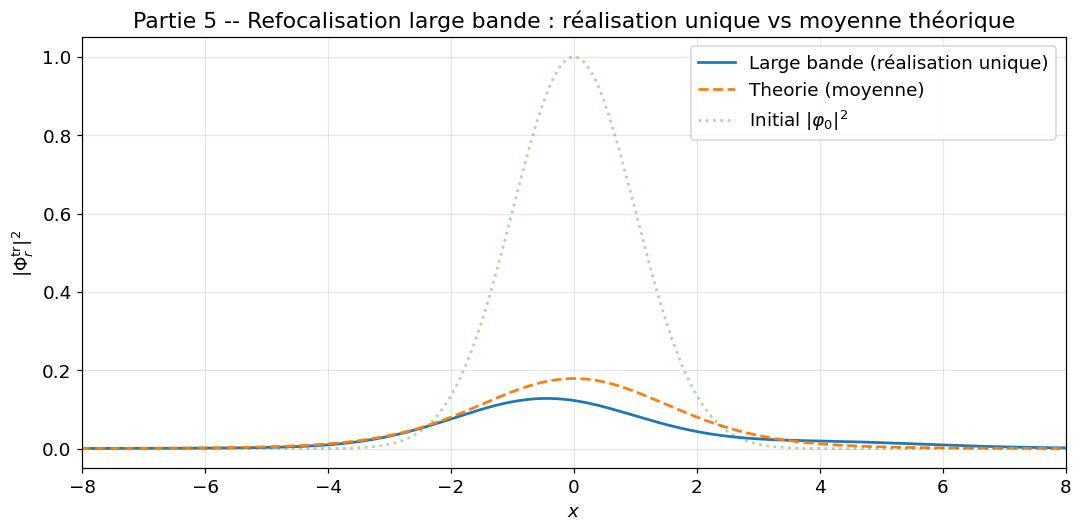

In [23]:
# Realisation unique de la refocalisation large bande
rng_bb = np.random.default_rng(42)
mu_slices_bb = generate_medium_slices(x, sigma, x_c, z_c, L, rng_bb)

Phi_r_bb_single = broadband_refocus_same_medium(phi0, x, r0, L, h, r_M_p5, omegas, mu_slices_bb)
Phi_theory_bb = broadband_theory_same_medium(x, r0, r_M_p5, omegas, L, gamma2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, np.abs(Phi_r_bb_single)**2, label='Large bande (réalisation unique)')
ax.plot(x, np.abs(Phi_theory_bb)**2, '--', label='Theorie (moyenne)')
ax.plot(x, np.abs(phi0)**2, ':', alpha=0.4, label='Initial $|\\varphi_0|^2$')
ax.set_xlim(-8, 8)
ax.set_xlabel('$x$')
ax.set_ylabel('$|\\Phi_r^{\\mathrm{tr}}|^2$')
ax.set_title('Partie 5 - Refocalisation large bande : réalisation unique vs moyenne théorique')
ax.legend()
fig.tight_layout()
fig.savefig('../report/figures/part5_broadband_single.pdf', bbox_inches='tight', dpi=150)
plt.show()

### Monte Carlo : champ refocalisé large bande moyen et stabilité statistique

In [24]:
n_mc_p5 = 50
mean_Phi_r_bb = np.zeros(N, dtype=complex)
mean_intens_bb = np.zeros(N)
all_Phi_r_bb_intens = []  # stocker les réalisations individuelles pour l'analyse de stabilité

rng_p5 = np.random.default_rng(999)

for i in tqdm(range(n_mc_p5), desc='Partie 5 - Monte Carlo (large bande)'):
    mu_slices_i = generate_medium_slices(x, sigma, x_c, z_c, L, rng_p5)
    Phi_r_i = broadband_refocus_same_medium(phi0, x, r0, L, h, r_M_p5, omegas, mu_slices_i)
    mean_Phi_r_bb += Phi_r_i
    mean_intens_bb += np.abs(Phi_r_i)**2
    all_Phi_r_bb_intens.append(np.abs(Phi_r_i)**2)

mean_Phi_r_bb /= n_mc_p5
mean_intens_bb /= n_mc_p5
all_Phi_r_bb_intens = np.array(all_Phi_r_bb_intens)

Partie 5 -- Monte Carlo (large bande):   0%|          | 0/50 [00:00<?, ?it/s]

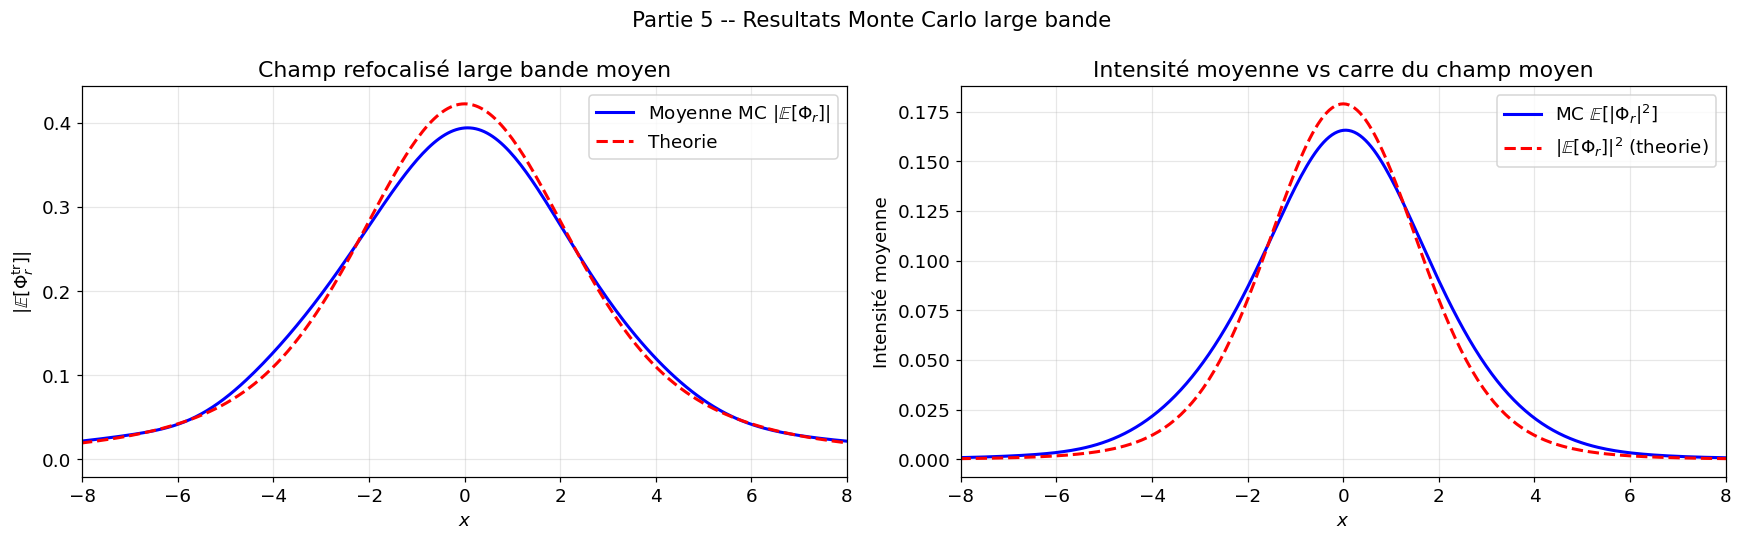

In [25]:
# Champ refocalisé large bande moyen
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(x, np.abs(mean_Phi_r_bb), 'b-', linewidth=2, label='Moyenne MC $|\\mathbb{E}[\\Phi_r]|$')
axes[0].plot(x, np.abs(Phi_theory_bb), 'r--', linewidth=2, label='Theorie')
axes[0].set_xlim(-8, 8)
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$|\\mathbb{E}[\\Phi_r^{\\mathrm{tr}}]|$')
axes[0].set_title('Champ refocalisé large bande moyen')
axes[0].legend()

axes[1].plot(x, mean_intens_bb, 'b-', linewidth=2, label='MC $\\mathbb{E}[|\\Phi_r|^2]$')
axes[1].plot(x, np.abs(Phi_theory_bb)**2, 'r--', linewidth=2, label='$|\\mathbb{E}[\\Phi_r]|^2$ (theorie)')
axes[1].set_xlim(-8, 8)
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('Intensité moyenne')
axes[1].set_title('Intensité moyenne vs carre du champ moyen')
axes[1].legend()

fig.suptitle('Partie 5 - Resultats Monte Carlo large bande', fontsize=14)
fig.tight_layout()
fig.savefig('../report/figures/part5_broadband_mean.pdf', bbox_inches='tight', dpi=150)
plt.show()

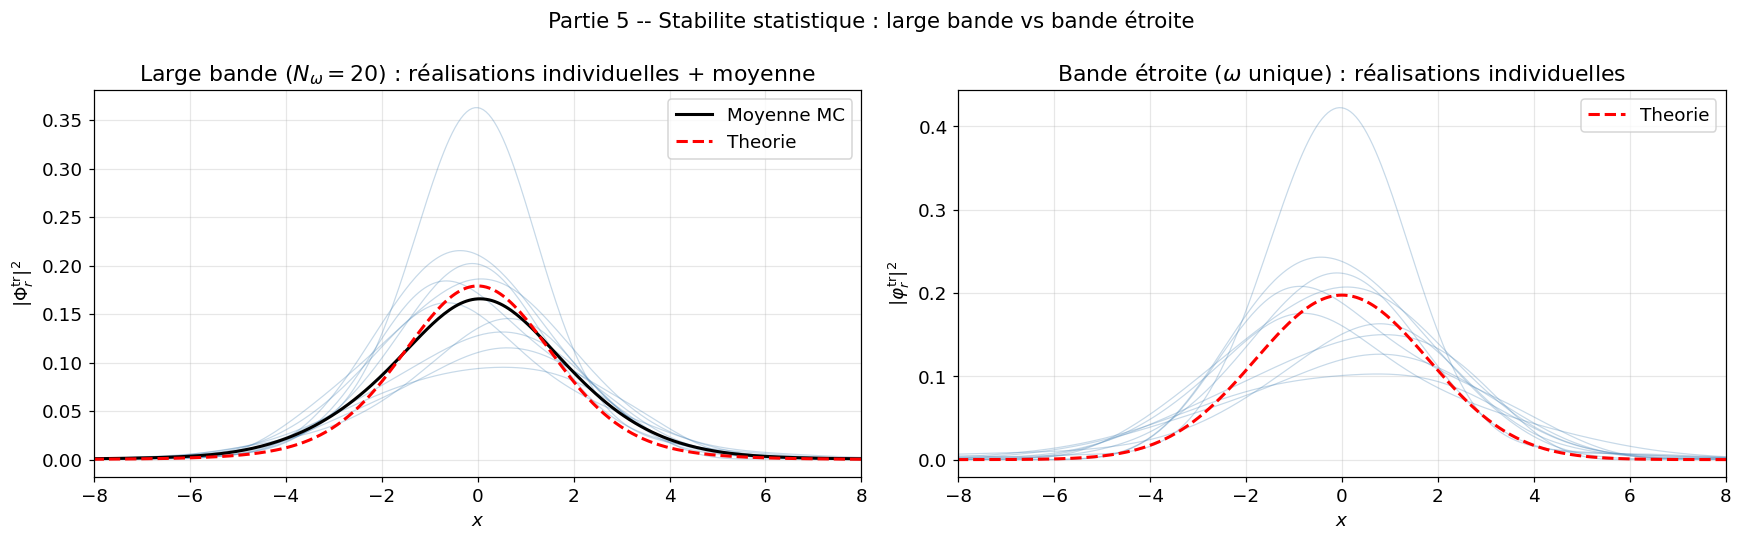

In [26]:
# Stabilite statistique : large bande vs bande étroite
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panneau gauche : réalisations large bande
n_show = min(10, n_mc_p5)
for i in range(n_show):
    axes[0].plot(x, all_Phi_r_bb_intens[i], alpha=0.3, linewidth=0.8, color='steelblue')
axes[0].plot(x, mean_intens_bb, 'k-', linewidth=2, label='Moyenne MC')
axes[0].plot(x, np.abs(Phi_theory_bb)**2, 'r--', linewidth=2, label='Theorie')
axes[0].set_xlim(-8, 8)
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$|\\Phi_r^{\\mathrm{tr}}|^2$')
axes[0].set_title(f'Large bande ($N_\\omega = {N_omega}$) : réalisations individuelles + moyenne')
axes[0].legend()

# Panneau droit : réalisations bande étroite (fréquence unique) pour comparaison
rng_nb = np.random.default_rng(999)  # même graine que le large bande
nb_realizations = []
for i in range(n_show):
    mu_slices_nb = generate_medium_slices(x, sigma, x_c, z_c, L, rng_nb)
    chi_nb = gaussian_mirror(x, r_M_p5)
    _, phi_r_nb = refocus_random_same_medium(phi0, x, k, L, h, chi_nb, mu_slices_nb)
    nb_realizations.append(np.abs(phi_r_nb)**2)
    axes[1].plot(x, np.abs(phi_r_nb)**2, alpha=0.3, linewidth=0.8, color='steelblue')

# Theorie bande étroite
theory_nb = mean_refocused_same_medium(x, r0, r_M_p5, k, L, omega, gamma2)
axes[1].plot(x, np.abs(theory_nb)**2, 'r--', linewidth=2, label='Theorie')
axes[1].set_xlim(-8, 8)
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$|\\varphi_r^{\\mathrm{tr}}|^2$')
axes[1].set_title('Bande étroite ($\\omega$ unique) : réalisations individuelles')
axes[1].legend()

fig.suptitle('Partie 5 - Stabilite statistique : large bande vs bande étroite', fontsize=14)
fig.tight_layout()
fig.savefig('../report/figures/part5_statistical_stability.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [27]:
# Quantifier la stabilité statistique
center_idx = N // 2

# Large bande : CV en x = 0
bb_peak_values = all_Phi_r_bb_intens[:, center_idx]
cv_broadband = np.std(bb_peak_values) / np.mean(bb_peak_values)

# Bande étroite : collecter les valeurs au pic de nouvelles réalisations
nb_peak_values = []
rng_nb2 = np.random.default_rng(999)
for i in range(n_mc_p5):
    mu_slices_nb2 = generate_medium_slices(x, sigma, x_c, z_c, L, rng_nb2)
    chi_nb2 = gaussian_mirror(x, r_M_p5)
    _, phi_r_nb2 = refocus_random_same_medium(phi0, x, k, L, h, chi_nb2, mu_slices_nb2)
    nb_peak_values.append(np.abs(phi_r_nb2[center_idx])**2)
nb_peak_values = np.array(nb_peak_values)
cv_narrowband = np.std(nb_peak_values) / np.mean(nb_peak_values)

print(f"Coefficient de variation en x = 0 (pic) :")
print(f"  Large bande   (N_omega = {N_omega}) : CV = {cv_broadband:.4f}")
print(f"  Bande étroite (omega unique) :      CV = {cv_narrowband:.4f}")
print(f"  Facteur de reduction :              {cv_narrowband / cv_broadband:.2f}x")

Coefficient de variation en x = 0 (pic) :
  Large bande   (N_omega = 20) : CV = 0.4942
  Bande étroite (omega unique) :      CV = 0.5259
  Facteur de reduction :              1.06x


Partie 5 -- Balayage de bande passante:   0%|          | 0/5 [00:00<?, ?it/s]

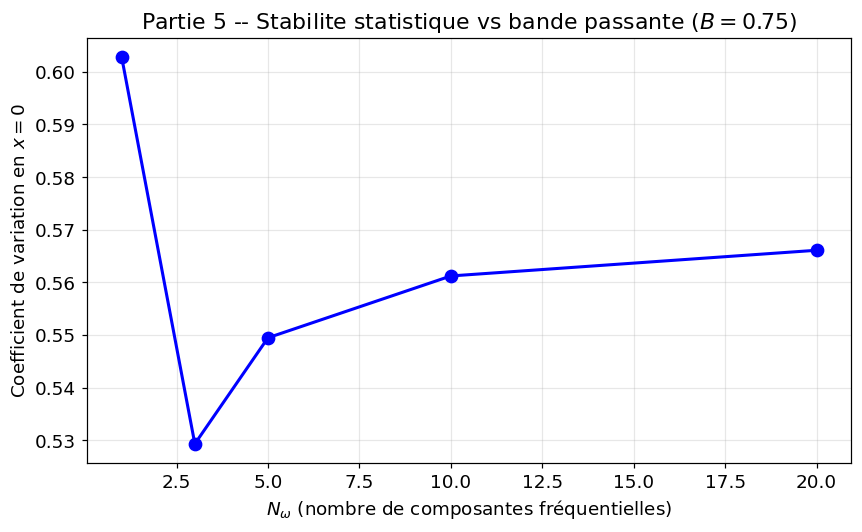

In [28]:
# Effet de la bande passante sur la stabilité
N_omega_list = [1, 3, 5, 10, 20]
n_mc_bw = 30
cv_values = []

for N_w in tqdm(N_omega_list, desc='Partie 5 - Balayage de bande passante'):
    if N_w == 1:
        omegas_w = np.array([omega_0])
    else:
        omegas_w = np.linspace(omega_0 - B, omega_0 + B, N_w)
    
    peaks_w = []
    rng_bw = np.random.default_rng(777)
    for i in range(n_mc_bw):
        mu_slices_bw = generate_medium_slices(x, sigma, x_c, z_c, L, rng_bw)
        Phi_r_bw = broadband_refocus_same_medium(phi0, x, r0, L, h, r_M_p5, omegas_w, mu_slices_bw)
        peaks_w.append(np.abs(Phi_r_bw[center_idx])**2)
    peaks_w = np.array(peaks_w)
    cv_values.append(np.std(peaks_w) / np.mean(peaks_w))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(N_omega_list, cv_values, 'bo-', markersize=8, linewidth=2)
ax.set_xlabel('$N_\\omega$ (nombre de composantes fréquentielles)')
ax.set_ylabel('Coefficient de variation en $x = 0$')
ax.set_title('Partie 5 - Stabilite statistique vs bande passante ($B = 0.75$)')
fig.tight_layout()
fig.savefig('../report/figures/part5_bandwidth_sweep.pdf', bbox_inches='tight', dpi=150)
plt.show()

**Observation (Partie 5) :**

1. **Les réalisations individuelles large bande** se regroupent etroitement autour du profil moyen théorique, tandis que les réalisations bande étroite presentent de grandes fluctuations. Cela confirme la **stabilité statistique** du retournement temporel large bande.

2. Le **coefficient de variation** au point focal diminue substantiellement avec le nombre croissant de composantes fréquentielles. Cela s'explique par le fait que différentes frequences subissent une diffusion statistiquement indépendante, de sorte que leurs contributions moyennent les fluctuations specifiques au milieu.

3. Une seule expérience large bande produit deja un profil refocalisé proche de la moyenne d'ensemble. C'est un avantage pratique essentiel : l'expérience n'à pas besoin d'être répétée pour observer le pic refocalisé.

4. L'intensité moyenne large bande $\mathbb{E}[|\Phi_r|^2]$ est proche de $|\mathbb{E}[\Phi_r]|^2$, confirmant davantage que le champ refocalisé large bande est quasi déterministe.


# Conclusion

Ce notebook a démontré les phénomènes clés de la refocalisation par retournement temporel dans l'approximation paraxiale (Schrödinger) :

1. **Partie 1 :** La méthode de propagation de Fourier reproduit exactement la solution analytique du faisceau gaussien dans un milieu homogène, validant notre cadre numérique.

2. **Partie 2 :** Le retournement temporel dans un milieu homogène n'atteint une refocalisation parfaite que lorsque l'ouverture du miroir ($r_M$) est suffisamment grande pour capturer l'intégralité du faisceau transmis. Les miroirs compact et gaussien presentent tous deux ce comportement. Le miroir gaussien admet une solution exacte en forme fermée.

3. **Partie 3 :** Dans un milieu aléatoire, le champ transmis moyen est atténué par le facteur de décohérence $\exp(-\gamma_0 \omega^2 L/8)$, tandis que l'intensité moyenne est préservée. Cela reflete la perte de cohérence de l'onde (scintillation) sans dissipation d'énergie. La méthode de Fourier à pas fractionnés avec génération de champs aléatoires par enchâssement circulant produit des moyennes Monte Carlo cohérentes avec la theorie.

4. **Partie 4 (super-résolution) :** Le retournement temporel à travers le **même** milieu aléatoire produit un faisceau refocalisé qui peut être **plus etroit** que la limite de diffraction imposée par l'ouverture du miroir seule. Le facteur gaussien supplementaire $\exp(-x^2/r_a^2)$ dans la formule du même milieu represente l'effet de super-résolution. Le milieu aléatoire agit effectivement comme une lentille de diffusion qui augmente l'ouverture numérique. En revanche, la rétro-propagation à travers un milieu homogène produit simplement une version globalement attenuee du champ refocalisé homogène.

5. **Partie 5 (stabilité statistique) :** La refocalisation par retournement temporel large bande est **auto-moyennante** : le profil d'intensité d'une seule expérience large bande converge vers sa moyenne statistique lorsque le nombre de composantes fréquentielles augmente. C'est un avantage pratique fondamental, car une seule expérience suffit pour observer une tache focale nette.